In [12]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [13]:
# Data Analyst jobs in India
df_DA_IND = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'India')
].copy()

# Remove missing salaries
df_DA_IND = df_DA_IND.dropna(subset=['salary_year_avg'])

# Explode skills column
df_DA_IND_exploded = df_DA_IND.explode('job_skills')

# Group by skill and calculate count + median salary
df_DA_skills = (
    df_DA_IND_exploded
    .groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
    .sort_values(by='count', ascending=False)
)

# Rename columns
df_DA_skills = df_DA_skills.rename(
    columns={
        'count': 'skill_count',
        'median': 'median_salary'
    }
)

# Total Data Analyst jobs
DA_job_count = len(df_DA_IND)

# Skill percentage
df_DA_skills['skill_percent'] = (
    df_DA_skills['skill_count']
    / DA_job_count
    * 100
)

skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > 5]
# Display result
df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,46,96050.00,48.936170
excel,39,98500.00,41.489362
python,36,96050.00,38.297872
tableau,20,108087.50,21.276596
r,18,79200.00,19.148936
power bi,17,111175.00,18.085106
azure,15,93600.00,15.957447
aws,12,79200.00,12.765957
oracle,11,79200.00,11.702128


<Figure size 1000x600 with 0 Axes>

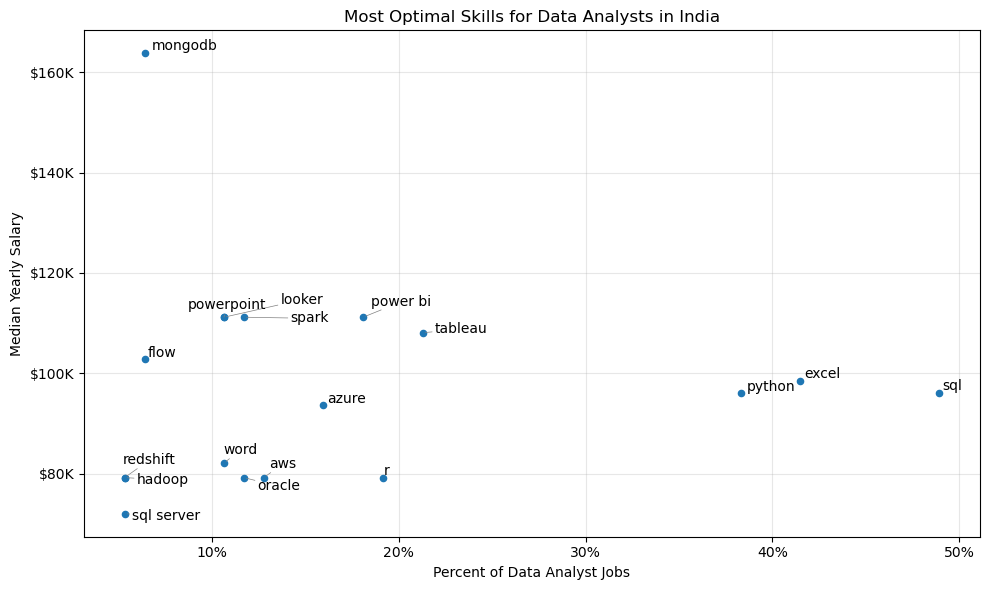

In [14]:
from adjustText import adjust_text
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

ax = df_DA_skills_high_demand.plot(
    kind='scatter',
    x='skill_percent',
    y='median_salary',
    figsize=(10, 6)
)

# Skill labels
texts = []

for i, skill in enumerate(df_DA_skills_high_demand.index):
    texts.append(
        plt.text(
            df_DA_skills_high_demand['skill_percent'].iloc[i],
            df_DA_skills_high_demand['median_salary'].iloc[i],
            skill,
            fontsize=10
        )
    )

# Avoid overlap
adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='-',
        color='gray',
        lw=0.5
    )
)

# Formatting
plt.title('Most Optimal Skills for Data Analysts in India')
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')

# X axis as %
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{x:.0f}%')
)

# Y axis as salary
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
df_DA_IND = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'India')
].copy()

df_DA_IND = df_DA_IND.dropna(subset=['salary_year_avg'])

df_DA_IND_exploded = df_DA_IND.explode('job_skills')

In [18]:
df_DA_skills = (
    df_DA_IND_exploded
    .groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
    .sort_values(by='count', ascending=False)
)

df_DA_skills = df_DA_skills.rename(
    columns={
        'count': 'skill_count',
        'median': 'median_salary'
    }
)

In [19]:
DA_job_count = len(df_DA_IND)

df_DA_skills['skill_percent'] = (
    df_DA_skills['skill_count']
    / DA_job_count
    * 100
)


skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[
    df_DA_skills['skill_percent'] > skill_percent
]

Create Technology Percentage

In [20]:
technology_dict = {
    'analyst_tools': [
        'excel',
        'power bi',
        'powerpoint',
        'tableau',
        'word'
    ],

    'programming': [
        'python',
        'r',
        'go'
    ],

    'databases': [
        'sql',
        'sql server'
    ],

    'cloud': [
        'aws',
        'azure',
        'oracle'
    ]
}

In [21]:
df_technology = pd.DataFrame(
    list(technology_dict.items()),
    columns=['technology', 'skills']
)

df_technology = df_technology.explode('skills')

Merging 

In [22]:
df_plot = df_DA_skills_high_demand.reset_index()

df_plot = df_plot.merge(
    df_technology,
    left_on='job_skills',
    right_on='skills',
    how='left'
)

df_plot

,job_skills,skill_count,median_salary,skill_percent,technology,skills
0,sql,46,96050.00,48.936170,databases,sql
1,excel,39,98500.00,41.489362,analyst_tools,excel
2,python,36,96050.00,38.297872,programming,python
3,tableau,20,108087.50,21.276596,analyst_tools,tableau
4,r,18,79200.00,19.148936,programming,r
5,power bi,17,111175.00,18.085106,analyst_tools,power bi
6,azure,15,93600.00,15.957447,cloud,azure
7,aws,12,79200.00,12.765957,cloud,aws
8,oracle,11,79200.00,11.702128,cloud,oracle
9,spark,11,111175.00,11.702128,NaN,NaN


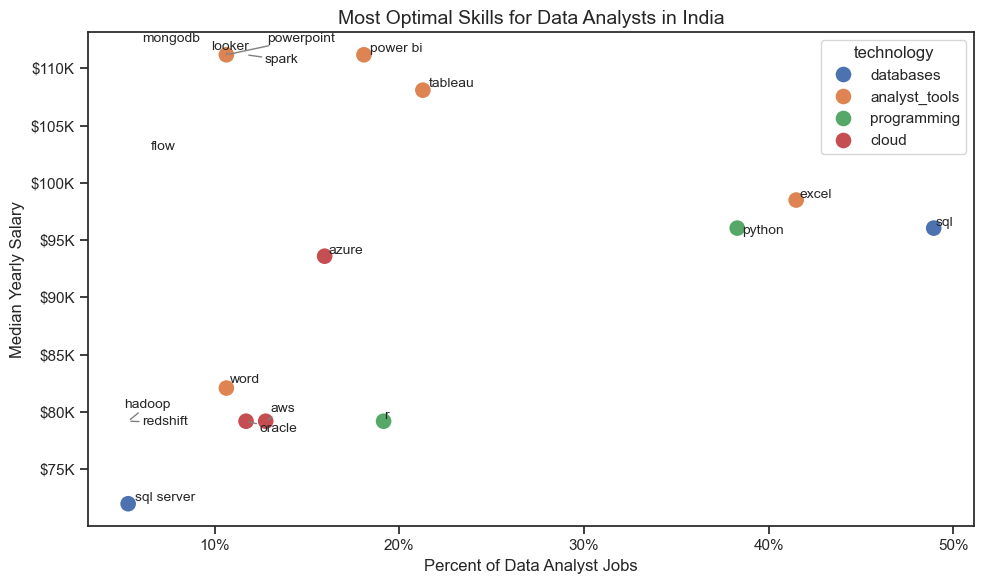

In [23]:
from adjustText import adjust_text
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='ticks')

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology',
    s=150
)


texts = []

for _, row in df_plot.iterrows():

    texts.append(
        plt.text(
            row['skill_percent'],
            row['median_salary'],
            row['job_skills'],
            fontsize=10
        )
    )

adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='-',
        color='gray'
    )
)


#Formatting

plt.title(
    'Most Optimal Skills for Data Analysts in India',
    fontsize=14
)

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'{x:.0f}%'
    )
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'${int(x/1000)}K'
    )
)

plt.legend(title='technology')

plt.tight_layout()
plt.show()

